In [1]:
import os,sys
os.environ['USE_PYGEOS'] = '0'

import geopandas as gpd
import pygeos
import pyproj
import numpy as np
import pandas as pd

from pathlib import Path
from shapely import LineString, Point, Polygon
import shapely

parent_dir = Path().resolve().parent
sys.path.insert(0, str(os.path.join(parent_dir,'src')))
from utils import *

In [2]:
# Import landuse sites
landuse_sites = gpd.read_file('../../cascading_failure/mapping_industries_economic_sectors/outputs/landuse_sites_osm_boundary.gpkg')
landuse_sites_gdf = gpd.GeoDataFrame(landuse_sites, geometry='geometry', crs='EPSG:4326')
landuse_sites_gdf = landuse_sites_gdf.to_crs(epsg=32648)
print(len(landuse_sites_gdf))

# Import industries
industries_df = gpd.read_file('../../cascading_failure/mapping_industries_economic_sectors/outputs/intersected_polygons.gpkg')
industries_gdf = gpd.GeoDataFrame(industries_df, geometry='geometry', crs='EPSG:4326')
industries_gdf = industries_gdf.rename(columns={'Unnamed: 0': 'industry_id', 'name_1': 'name'})
industries_gdf = industries_gdf.to_crs(epsg=32648)
# industries_gdf['area'] = industries_gdf['geometry'].apply(lambda geom: geom.area)
industries_gdf['geometry'] = industries_gdf['geometry'].apply(convert_to_point)

# Import nodes_gdftations from table_nodes_500m.gpkg
nodes_gdf =  gpd.read_file("../outputs/table_nodes_500m_update.gpkg")

# Import electricity demand statistics
sector_demand_df = pd.read_excel('../../cascading_failure/mapping_industries_economic_sectors/inputs/sectors_searchstrings_full.xlsx')

2064


/scistor/ivm/mye500/miniconda3/envs/py310/lib/python3.10/site-packages/geopandas/geoseries.py:645: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  result = super().apply(func, convert_dtype=convert_dtype, args=args, **kwargs)


In [3]:
nodes_gdf.head()

,NodeID,Voltage,lon,lat,Index,lines_count,cables_count,Capacity,geometry
0,153608703,110,610714.852695,2.315181e+06,153608703a,4,24,2400,POINT (610714.853 2315180.700)
1,2,110,672622.408581,1.278800e+06,0002,1,6,600,POINT (672622.409 1278800.027)
2,4,220,682154.017051,2.315888e+06,0004a,6,60,24000,POINT (682154.017 2315887.790)
3,241065371,110,684889.726446,2.304274e+06,241065371a,3,18,1800,POINT (684889.726 2304273.827)
4,241065371,220,684710.914392,2.304283e+06,241065371b,4,24,9600,POINT (684710.914 2304282.784)


In [4]:
# print(nodes_gdf['Capacity'].sum()*0.54)
# print(len(industries_gdf))
# print(nodes_gdf['Capacity'].sum()*0.54 / len(industries_gdf))

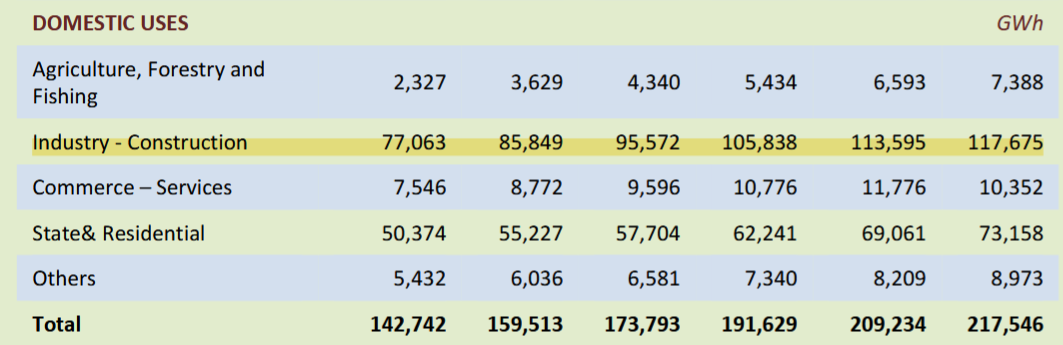
industries_gdf['required_capacity'] = nodes_gdf['Capacity'].sum()***0.54** / len(industries_gdf)

**0.54** represents the proportion of industrial use in the total electricity: 117675/217546=0.54.

In [ ]:
# Step 1: Count the number of each Sector_id in industries_gdf
sector_counts = industries_gdf.groupby('Sector_id').size()
print(sector_counts)

# Step 2: Distribute the total electricity_demand in sector_demand_df to each industry_id under each Sector_id
# Create a mapping from sector_id to total_demand
sector_demand_dict = sector_demand_df.set_index('sector_id')['electricity_demand'].to_dict()

# Step 3: Add electricity_demand and required_capacity to industries_gdf
# The total electricity demand for each Sector_id / the number of industries under that Sector_id, to get the electricity demand for each industry_id
industries_gdf['electricity_demand'] = industries_gdf['Sector_id'].map(sector_demand_dict) / industries_gdf['Sector_id'].map(sector_counts)
# industries_gdf['required_capacity'] = nodes_gdf['Capacity'].sum() * 0.54 / len(industries_gdf)
industries_gdf['required_capacity'] = nodes_gdf['Capacity'].sum() / len(industries_gdf)

# Step 4: Sum the electricity_demand and required_capacity, respectively,
# for all industries_gdf records with the same osmid, and assign it to the corresponding osmid in landuse_sites_gdf
# Aggregate the electricity_demand of all industries in industries_gdf by osmid
aggregated_demand = industries_gdf.groupby('osmid')['electricity_demand'].sum().rename('total_electricity_demand')
aggregated_capacity = industries_gdf.groupby('osmid')['required_capacity'].sum().rename('total_required_capacity')

# Merge the aggregated results into landuse_sites_gdf
landuse_sites_gdf = landuse_sites_gdf.merge(aggregated_demand, how='left', left_on='osmid', right_index=True)
landuse_sites_gdf = landuse_sites_gdf.merge(aggregated_capacity, how='left', left_on='osmid', right_index=True)
print(len(landuse_sites_gdf))
landuse_sites_gdf_cleaned = landuse_sites_gdf.dropna(subset=['total_electricity_demand'])
print(len(landuse_sites_gdf_cleaned))

Sector_id
1     650
2     376
3     128
4     360
5     128
6     637
7     743
8     642
9     171
10    777
11    749
12    614
13    668
14    415
dtype: int64
2064
1397


In [6]:
landuse_sites_gdf_cleaned.head(2)

,element_type,osmid,nodes,landuse,name,name:en,operator,owner,plant:method,plant:output:electricity,...,name:th,addr:hamlet,port:type,ruins,addr:district:en,addr:province:en,addr:subdistrict:en,geometry,total_electricity_demand,total_required_capacity
0,way,876508089,"[8157751794, 8157751793, 8157751792, 815775179...",industrial,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((521908.382 994781.312, 521831.348 99...",34.098949,4132.332105
1,way,876286185,"[8155710983, 8155710982, 8155710981, 815571098...",industrial,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((517082.121 1012145.562, 517013.270 1...",34.098949,4132.332105


In [33]:
results_dict = {}
# need to set the distance_threshold larger than 60 km to ensure all landuse sites have corresponding substations????????????????????
distance_threshold = 600000

# Iterate through each landuse site and calculate the distance to each substation
for idx, landuse_site in landuse_sites_gdf_cleaned.iterrows():
    landuse_site_id = landuse_site['osmid']
    distances = nodes_gdf.geometry.distance(landuse_site.geometry)  # Calculate the distance to each substation
    
    # Initialize the dictionary for the current site
    results_dict[landuse_site_id] = {}
    weights = {}
    
    for sub_idx, distance in distances.items():
        if distance > 0 and distance <= distance_threshold:  # Exclude distances of 0 and those exceeding the threshold
            sub_id = nodes_gdf.at[sub_idx, 'Index']
            capacity = nodes_gdf.at[sub_idx, 'Capacity']
            weight = capacity / distance  # Calculate the weight
            weights[sub_id] = weight

            # Save the detailed information of the substation
            results_dict[landuse_site_id][sub_id] = {
                'distance': distance,
                'capacity': capacity,
                'weight': weight
            }

    # Normalize weights
    max_weight = max(weights.values())
    min_weight = min(weights.values())
    weight_range = max_weight - min_weight
    
    for sub_id in weights:
        normalized_weight = (weights[sub_id] - min_weight) / weight_range if weight_range > 0 else 0
        results_dict[landuse_site_id][sub_id]['normalized_weight'] = normalized_weight


In [35]:
results_dict = {}
# need to set the distance_threshold larger than 60 km to ensure all landuse sites have corresponding substations
distance_threshold = 600000000000000
subs_gdf = nodes_gdf[nodes_gdf['NodeID'].astype(str).str.len() > 6]

# Iterate through each landuse site and calculate the distance to each substation
for idx, landuse_site in landuse_sites_gdf_cleaned.iterrows():
    landuse_site_id = landuse_site['osmid']
    distances = subs_gdf.geometry.distance(landuse_site.geometry)  # Calculate the distance to each substation
    
    # Initialize the dictionary for the current site
    results_dict[landuse_site_id] = {}
    weights = {}
    
    for sub_idx, distance in distances.items():
        if distance > 0 and distance <= distance_threshold:  # Exclude distances of 0 and those exceeding the threshold
            sub_id = subs_gdf.at[sub_idx, 'NodeID']
            capacity = subs_gdf.at[sub_idx, 'Capacity']
            weight = capacity / distance  # Calculate the weight
            weights[sub_id] = weight

            # Save the detailed information of the substation
            results_dict[landuse_site_id][sub_id] = {
                'distance': distance,
                'capacity': capacity,
                'weight': weight
            }

    # Normalize weights
    max_weight = max(weights.values())
    min_weight = min(weights.values())
    weight_range = max_weight - min_weight
    
    for sub_id in weights:
        normalized_weight = (weights[sub_id] - min_weight) / weight_range if weight_range > 0 else 0
        results_dict[landuse_site_id][sub_id]['normalized_weight'] = normalized_weight


In [31]:
results_dict.keys()

dict_keys([876508089, 876286185, 876286186, 876508090, 876286177, 876286176, 876286175, 1023929748, 876286182, 16417550, 16417551, 243532282, 548970111, 671242108, 876568820, 1041342437, 876286192, 877500573, 877500572, 876286201, 669691883, 876286194, 669124944, 225364164, 877500574, 877467451, 876521121, 877500564, 877500565, 798521971, 877500558, 169087614, 876521099, 876521100, 537845763, 876547184, 877504138, 537845449, 876547187, 169077621, 876547186, 876547191, 876547189, 876547190, 857503183, 857503185, 169077623, 225085127, 876521105, 876521106, 876521107, 876521108, 857503187, 876521104, 857503189, 857503190, 169077622, 875074146, 734940044, 876547181, 168090020, 876286204, 876286202, 876286203, 554382243, 288582904, 857523778, 1184994504, 1134731178, 1177836563, 475301776, 597902555, 795539563, 1041311775, 1041311776, 648723263, 1041307279, 1039481031, 1017066826, 576360514, 857555008, 544406426, 649734840, 857555002, 876286207, 857555029, 649734837, 649734839, 649734838, 61

In [36]:
top_subs = sorted(results_dict[876508089].items(), key=lambda x: x[1]['normalized_weight'], reverse=True)[:10]

for sub_id, info in top_subs:
    print(f"sub_id: {sub_id}, weight: {info['normalized_weight']}, distance: {info['distance']}")

sub_id: 548970112, weight: 1.0, distance: 30876.70197733485
sub_id: 1052212132, weight: 0.4685309257671583, distance: 3088.5419021364837
sub_id: 549005377, weight: 0.1834913526490756, distance: 105094.47897032162
sub_id: 548970103, weight: 0.17854145812202718, distance: 27001.365592434544
sub_id: 1052065872, weight: 0.14799840216734234, distance: 156324.52703575033
sub_id: 745348908, weight: 0.1312535582121381, distance: 264364.5760248935
sub_id: 272740093, weight: 0.12923183156256718, distance: 268495.1248274379
sub_id: 548970109, weight: 0.12850664285182517, distance: 30000.930399390694
sub_id: 1051907167, weight: 0.1215565133051813, distance: 190283.79492216225
sub_id: 1216970886, weight: 0.10400740747584612, distance: 268660.7506384328


In [23]:
# Initialize the minimum distance as None
min_distance = None

# Iterate through each landuse site
for landuse_site_id, subs_info in results_dict.items():
    # Iterate through each substation
    for sub_id, info in subs_info.items():
        distance = info['distance']
        
        # Update the minimum distance
        if min_distance is None or distance < min_distance:
            min_distance = distance

# Output the minimum distance
if min_distance is not None:
    print("All distances' minimum value:", min_distance)
else:
    print("No distances found.")

All distances' minimum value: 1.6907941388785408


In [24]:
def get_top_subs(results_dict, landuse_site_id):
    # Get all substation information for the given landuse site
    if landuse_site_id in results_dict:
        # Sort substation information by weight and take the top 1000???????????
        top_subs = sorted(results_dict[landuse_site_id].items(), key=lambda item: item[1]['normalized_weight'], reverse=True)[:10]

        output = []
        for sub_id, info in top_subs:
            output.append({
                'sub_id': sub_id,
                'distance': info['distance'],
                'capacity': info['capacity'],
                'normalized_weight': info['normalized_weight']
                })
        return pd.DataFrame(output)
        
    else:
        print(f"Landuse site ID '{landuse_site_id}' not found in results_dict.")
        return None

In [37]:
get_top_subs(results_dict, 876508089)

,sub_id,distance,capacity,normalized_weight
0,548970112,30876.701977,38400,1.000000
1,1052212132,3088.541902,1800,0.468531
2,549005377,105094.478970,24000,0.183491
3,548970103,27001.365592,6000,0.178541
4,1052065872,156324.527036,28800,0.147998
5,745348908,264364.576025,43200,0.131254
6,272740093,268495.124827,43200,0.129232
7,548970109,30000.930399,4800,0.128507
8,1051907167,190283.794922,28800,0.121557
9,1216970886,268660.750638,34800,0.104007


In [38]:
top_subs_dict = {}

# Iterate through each landuse_site_id in results_dict and calculate its top_subs
for landuse_site_id in results_dict:
    top_subs_df = get_top_subs(results_dict, landuse_site_id)
    if top_subs_df is not None:
        # Convert top_subs_df to a dictionary and store it in top_subs_dict
        top_subs_dict[landuse_site_id] = top_subs_df.to_dict(orient='records')

In [39]:
top_subs_dict[876508089]

[{'sub_id': 548970112,
  'distance': 30876.70197733485,
  'capacity': 38400,
  'normalized_weight': 1.0},
 {'sub_id': 1052212132,
  'distance': 3088.5419021364837,
  'capacity': 1800,
  'normalized_weight': 0.4685309257671583},
 {'sub_id': 549005377,
  'distance': 105094.47897032162,
  'capacity': 24000,
  'normalized_weight': 0.1834913526490756},
 {'sub_id': 548970103,
  'distance': 27001.365592434544,
  'capacity': 6000,
  'normalized_weight': 0.17854145812202718},
 {'sub_id': 1052065872,
  'distance': 156324.52703575033,
  'capacity': 28800,
  'normalized_weight': 0.14799840216734234},
 {'sub_id': 745348908,
  'distance': 264364.5760248935,
  'capacity': 43200,
  'normalized_weight': 0.1312535582121381},
 {'sub_id': 272740093,
  'distance': 268495.1248274379,
  'capacity': 43200,
  'normalized_weight': 0.12923183156256718},
 {'sub_id': 548970109,
  'distance': 30000.930399390694,
  'capacity': 4800,
  'normalized_weight': 0.12850664285182517},
 {'sub_id': 1051907167,
  'distance': 1

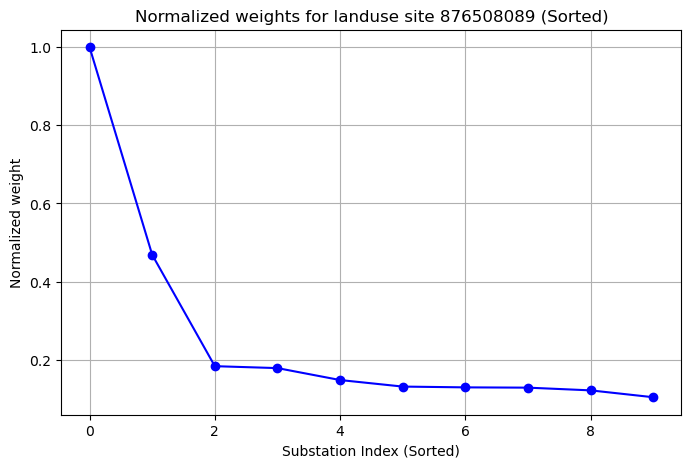

In [40]:
import matplotlib.pyplot as plt

landuse_site = results_dict[876508089]
weights = [data['normalized_weight'] for sub, data in landuse_site.items()]

# Sort weights in descending order
weights_sorted = sorted(weights, reverse=True)[:10]

# Plot the curve
plt.figure(figsize=(8, 5))
plt.plot(weights_sorted, marker='o', linestyle='-', color='b')
plt.title('Normalized weights for landuse site 876508089 (Sorted)')
plt.xlabel('Substation Index (Sorted)')
plt.ylabel('Normalized weight')
plt.grid(True)
plt.show()

In [ ]:
# nodes_gdf =  gpd.read_file("../outputs/table_nodes_500m_update.gpkg")
# subs_gdf = nodes_gdf[nodes_gdf['NodeID'].astype(str).str.len() > 6]

# print(len(subs_gdf))
# subs_gdf = subs_gdf.drop_duplicates(subset='NodeID')
# print(len(subs_gdf))

In [41]:
landuse_sites_gdf_add_bus = landuse_sites_gdf_cleaned.copy()
nodes_gdf_new = nodes_gdf.copy()

# First, ensure the 'BusID' column is created in landuse_sites_gdf_add_bus, if not, create it as an empty column
landuse_sites_gdf_add_bus['BusID'] = None

# Iterate through each landuse_site_id in top_subs_dict
for landuse_site_id, subs_info in top_subs_dict.items():
    if subs_info:  # Ensure subs_info is not empty
        required_capacity = landuse_sites_gdf_add_bus.loc[
            landuse_sites_gdf_add_bus['osmid'] == landuse_site_id, 'total_required_capacity'
            ].values[0]
        
        for sub in subs_info:
            sub_id = sub['sub_id']
            sub_capacity = nodes_gdf_new.loc[nodes_gdf_new['Index'] == sub_id, 'Capacity'].values[0]
            
            if required_capacity <= sub_capacity:
                # Update the BusID column in landuse_sites_gdf_add_bus
                landuse_sites_gdf_add_bus.loc[landuse_sites_gdf_add_bus['osmid'] == landuse_site_id, 'BusID'] = sub_id
                # Subtract the required_capacity of the landuse_site
                nodes_gdf_new.loc[nodes_gdf_new['Index'] == sub_id, 'Capacity'] -= int(required_capacity)
                break  # Exit the loop after finding a suitable sub_id
            # else:
            #     # If the current substation's capacity is insufficient, skip this substation
            #     continue

landuse_sites_gdf_add_bus.head()

IndexError: index 0 is out of bounds for axis 0 with size 0

In [42]:
# Ensure NodeID and NodeID types are consistent
# landuse_sites_gdf_add_bus['BusID'] = landuse_sites_gdf_add_bus['BusID'].astype(str)
# nodes_gdf['Index'] = nodes_gdf['Index'].astype(str)

# Merge the two GeoDataFrames based on NodeID
data = landuse_sites_gdf_add_bus.merge(nodes_gdf, left_on='BusID', right_on='Index', how='inner')

# Group by NodeID and summarize
summary = data.groupby('BusID').agg(
    Total_Capacity=('Capacity', 'first'),
    Number_of_Connected_Landuse_Sites=('total_required_capacity', 'count'),
    Total_Required_Capacity=('total_required_capacity', 'sum'),
).reset_index()

# Calculate capacity usage percentage
summary['Capacity_Usage_Percent (%)'] = (summary['Total_Required_Capacity'] / summary['Total_Capacity'] * 100).round(2)

summary

,BusID,Total_Capacity,Number_of_Connected_Landuse_Sites,Total_Required_Capacity,Capacity_Usage_Percent (%)


In [44]:
landuse_sites_gdf_add_bus.to_excel('../../cascading_failure/mapping_industries_economic_sectors/outputs/landuse_sites_gdf_add_bus.xlsx', index=False)
landuse_sites_gdf_add_bus.to_file('../../cascading_failure/mapping_industries_economic_sectors/outputs/landuse_sites_gdf_add_bus.gpkg', driver='GPKG', crs='EPSG:32648')